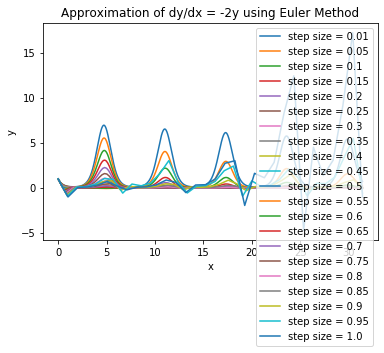

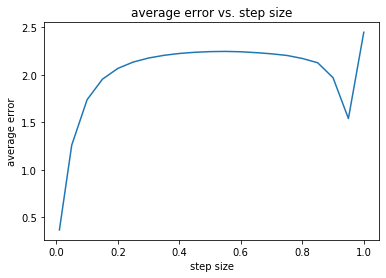

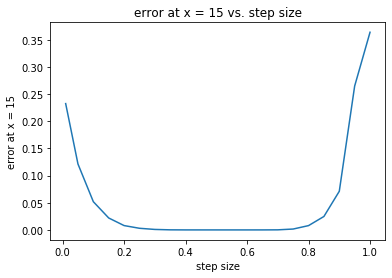

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def exactSolution(x_start, x_end, h, y0, coef):
    num_steps = int((x_end - x_start) / h) + 1
    x_values = np.linspace(x_start, x_end, num_steps)
    y_values = y0 * np.exp(coef * np.sin(x_values))
    return y_values

def errorCalc(y_exact, y_approx):
    local_error = abs(y_exact - y_approx)
    return local_error, sum(local_error)

def euler(x_start, x_end, h):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1
    error_15 = 0
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        if (abs(x_values[i] - 15) <= (h/2)):
            error_15 = y_values[i]
    plt.plot(x_values, y_values, label=f"step size = {h}")
    local_error, global_error = errorCalc(exactSolution(x_start, x_end, h, 1, -2), y_values)
    return local_error, global_error, error_15
    
x_start, x_end = 0, 10 * np.pi
local_errors = [[] for k in range(0,21)] #chatGPT used to understand how to make empty array with only number of rows "how do you make a 2d array in python only knowing the number of rows"
global_errors = np.zeros(21)
error_15s = np.zeros(21)
h = [0.01] + [round(0.05 * i, 2) for i in range(1, 21)] #chatGPT used "Make a list in python that follows (0.01,0.05,0.1,0.15...1)"
local_errors[0], global_errors[0], error_15s[0] = euler(x_start, x_end, h[0])
for i in range (1,21):
    local_errors[i], global_errors[i], error_15s[i] = euler(x_start, x_end, h[i])
avg_errors = [[] for l in range(0,21)]
for m in range (0,21):
    avg_errors[m] = np.mean(local_errors[m])

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Approximation of dy/dx = -2y using Euler Method')
plt.show()

plt.plot(h, avg_errors)
plt.xlabel('step size')
plt.ylabel('average error')
plt.title('average error vs. step size')
plt.show()

plt.plot(h, error_15s)
plt.xlabel('step size')
plt.ylabel('error at x = 15')
plt.title('error at x = 15 vs. step size')
plt.show()

We're seeing a better approximation and less error with smaller step sizes because it revaluates the euler method and takes a new derivative more frequently, meaning it stays closer to the true curve longer.

Addendum:

lambda = -2cos(x)

stability condition: abs{1+h(-2cos(x))} <= 1
- min(cos(x)) = 0
- for this case: h can equal anything
- max(cos(x)) = 1
- in this case (the most restrictive one): 0 <= h <= 1
- h can not be negative so h <= 1 ensures stability